In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import gensim
from gensim.models import KeyedVectors

print('Import hotový.')
print(f'gensim verze: {gensim.__version__}')

Import hotový.
gensim verze: 4.4.0


In [12]:
# Cesta k modelu (sdílená složka data/ v repozitáři)
MODEL_PATH = '../data/cc.cs.300.vec'

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'Chybí soubor: {MODEL_PATH}\n')
else:
    size_mb = os.path.getsize(MODEL_PATH) / 1_048_576
    print(f'Model nalezen: {MODEL_PATH}  ({size_mb:.0f} MB)')

Model nalezen: ../data/cc.cs.300.vec  (4310 MB)


In [13]:
# Načtení modelu — gensim KeyedVectors (.vec formát)
# limit=200_000 načte pouze prvních 200 000 slov (dostatečné pro cvičení)
wv = KeyedVectors.load_word2vec_format(
    MODEL_PATH,
    binary=False,
    limit=200_000
)

VOCAB     = wv.index_to_key        # Seznam slov
VOCAB_SET = set(VOCAB)             # Pro rychlé vyhledávání
DIM       = wv.vector_size         # Dimenze vektoru = 300

print(f'Model načten: {len(VOCAB):,} slov, dimenze = {DIM}')

Model načten: 200,000 slov, dimenze = 300


In [14]:
def get_vector(word: str) -> "np.ndarray":
    """Vrátí embedding vektor pro dané slovo. Vyvolá KeyError pokud slovo není ve slovníku."""
    return wv[word]


def cosine_similarity(v1, v2) -> float:
    """Kosinová podobnost dvou vektorů."""
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return float(np.dot(v1, v2) / (norm1 * norm2))


def most_similar(vector, n: int = 10, exclude_words=None) -> list:
    """
    Vrátí n nejbližších slov (dle kosinové podobnosti) k zadanému vektoru.
    exclude_words: seznam slov, která se mají z výsledků vyloučit.
    """
    if exclude_words is None:
        exclude_words = set()
    else:
        exclude_words = set(exclude_words)
    results = wv.similar_by_vector(vector, topn=n + len(exclude_words) + 5)
    filtered = [(w, s) for w, s in results if w not in exclude_words]
    return filtered[:n]


print("Funkce get_vector, cosine_similarity, most_similar definovány.")

Funkce get_vector, cosine_similarity, most_similar definovány.


In [15]:
# Demonstrace základních operací

# 1) Výpis vektoru
vec_kral = get_vector("král")
print(f"Vektor slova \"král\" (prvních 10 dimenzí): {vec_kral[:10]}")
print(f"Norma vektoru: {np.linalg.norm(vec_kral):.4f}")

# 2) Podobnost dvou slov
pairs = [
    ("pes", "kočka"),
    ("pes", "auto"),
    ("muž", "žena"),
    ("radost", "smutek"),
]

print("\nKosinová podobnost vybraných párů slov:")
print(f"{'Slovo 1':<15} {'Slovo 2':<15} {'Podobnost':>10}")
print("-" * 42)
for w1, w2 in pairs:
    sim = cosine_similarity(get_vector(w1), get_vector(w2))
    print(f"{w1:<15} {w2:<15} {sim:>10.4f}")

# 3) Nejbližší sousedé
print("\nNejbližší sousedé slova \"Praha\":")
for word, sim in most_similar(get_vector("Praha"), n=8, exclude_words=["Praha"]):
    print(f"  {word:<20} {sim:.4f}")

Vektor slova "král" (prvních 10 dimenzí): [-0.0506 -0.0281 -0.002  -0.1171  0.0528  0.0241  0.1022  0.0103 -0.0225
  0.1622]
Norma vektoru: 1.4014

Kosinová podobnost vybraných párů slov:
Slovo 1         Slovo 2          Podobnost
------------------------------------------
pes             kočka               0.5977
pes             auto                0.3343
muž             žena                0.7235
radost          smutek              0.4455

Nejbližší sousedé slova "Praha":
  Praha-               0.6522
  Brno                 0.6221
  Holešovice           0.6065
  1Praha               0.5948
  Uhříněves            0.5815
  Ostrava              0.5804
  PRAHA                0.5737
  2Praha               0.5698


**Interpretace výsledků:**

Embeddingy zachycují sémantickou blízkost slov:
- `pes`–`kočka` mají vysokou podobnost (obě jsou domácí zvířata),
- `pes`–`auto` mají nízkou podobnost (zcela odlišné kategorie),
- `muž`–`žena` jsou sice opačná pohlaví, ale sémanticky blízká (oba jsou lidé),
- `radost`–`smutek` jsou si podobné jako emoce, přestože mají opačnou valenci.

Nejbližší sousedé Prahy zahrnují česká města (Brno, Ostrava) a pražské čtvrti (Holešovice), ale také **šumové tokeny** (`Praha-`, `1Praha`, `PRAHA`, `2Praha`).

---
## Sekce 2 – Analýza embedding prostoru

Operace `v(b) - v(a) + v(c)` by měla přibližovat odpověď `d` v analogii `a : b = c : d`.

In [16]:
def analogy(a: str, b: str, c: str, n: int = 5) -> list:
    """
    Vrátí n nejbližších sousedů pro vektor v(b) - v(a) + v(c).
    Analogie: a : b = c : ?
    """
    missing = [w for w in (a, b, c) if w not in VOCAB_SET]
    if missing:
        print(f"  Slova mimo slovník: {missing}")
        return []
    query = get_vector(b) - get_vector(a) + get_vector(c)
    return most_similar(query, n=n, exclude_words=[a, b, c])

In [ ]:
analogie_testy = [
    ("Česko",  "Praha",    "Německo",  "Hlavní město Německa"),
    ("muž",    "král",     "žena",     "Ženský protějšek krále"),
    ("léto",   "letní",    "zima",     "Zimní obdoba slova letní"),
    ("řídit",  "auto",     "letět",    "Čím se letí"),
    ("muž",    "doktor",   "žena",     "Ženský protějšek doktora"),
    ("otec",   "syn",      "matka",    "Ženský protějšek syna"),
    ("Paříž",  "Francie",  "Berlín",   "Stát hlavního města Berlín"),
]

print("=== ANALOGIE v(b) - v(a) + v(c) ===\n")
print(f"{'a':<12} {'b':<12} {'c':<12}  Výsledky (top 5)")
print("=" * 80)

for a, b, c, hint in analogie_testy:
    results = analogy(a, b, c, n=5)
    top_words = ", ".join(f"{w} ({s:.3f})" for w, s in results)
    print(f"{a:<12} {b:<12} {c:<12}  {top_words}")
    print(f"  [{hint}]")
    print()

=== ANALOGIE v(b) - v(a) + v(c) ===

a            b            c             Výsledky (top 5)
Česko        Praha        Německo       Praha- (0.446), 1Praha (0.428), Holešovice (0.418), 2Praha (0.415), PrahaPraha (0.414)
  [Hlavní město Německa]

muž          král         žena          královna (0.673), princezna (0.549), krále (0.520), královnou (0.511), Královna (0.509)
  [Ženský protějšek krále]

léto         letní        zima          zimní (0.575), studená (0.510), mrazivá (0.502), Zimní (0.491), chladná (0.473)
  [Zimní obdoba slova letní]

řídit        auto         letět         letadlo (0.588), vozidlo (0.484), odletět (0.473), letadlem (0.471), letenku (0.470)
  [Čím se letí]

muž          doktor       žena          doktorka (0.593), gynekoložka (0.477), docentka (0.471), lékařka (0.470), Doktorka (0.459)
  [Ženský protějšek doktora]

otec         syn          matka         dcera (0.844), dcerka (0.681), manželka (0.678), vnučka (0.669), vnuk (0.619)
  [Ženský protějšek syna]


**Zhodnocení kvality analogií:**

Genderové analogie (`muž–král–žena → královna`, `otec–syn–matka → dcera`) fungují výborně díky jasnému sémantickému signálu v textech.

Geografická analogie `Česko–Praha–Německo → Berlín` **selhává** — místo Berlína vrací šumové tokeny (`Praha-`, `1Praha`, `PrahaPraha`). 

Obecné pravidlo platí: čím čistší a konzistentnější je sémantický vztah v textech, tím spolehlivější je výsledek. Geografické vztahy pro výrazně frekventovaná místní jména mohou být narušeny právě tímto typem šumu.

Celkem slov pro vizualizaci: 39


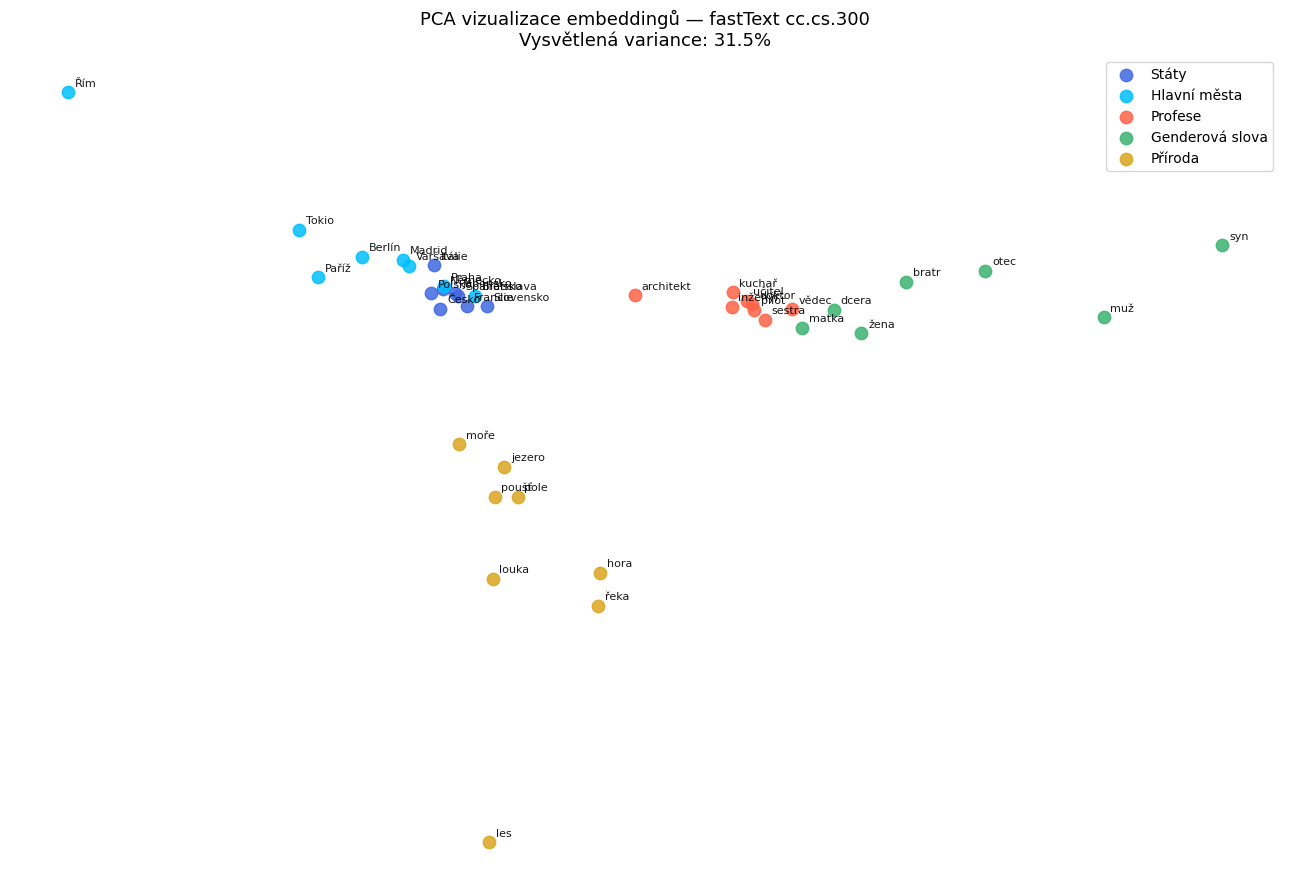

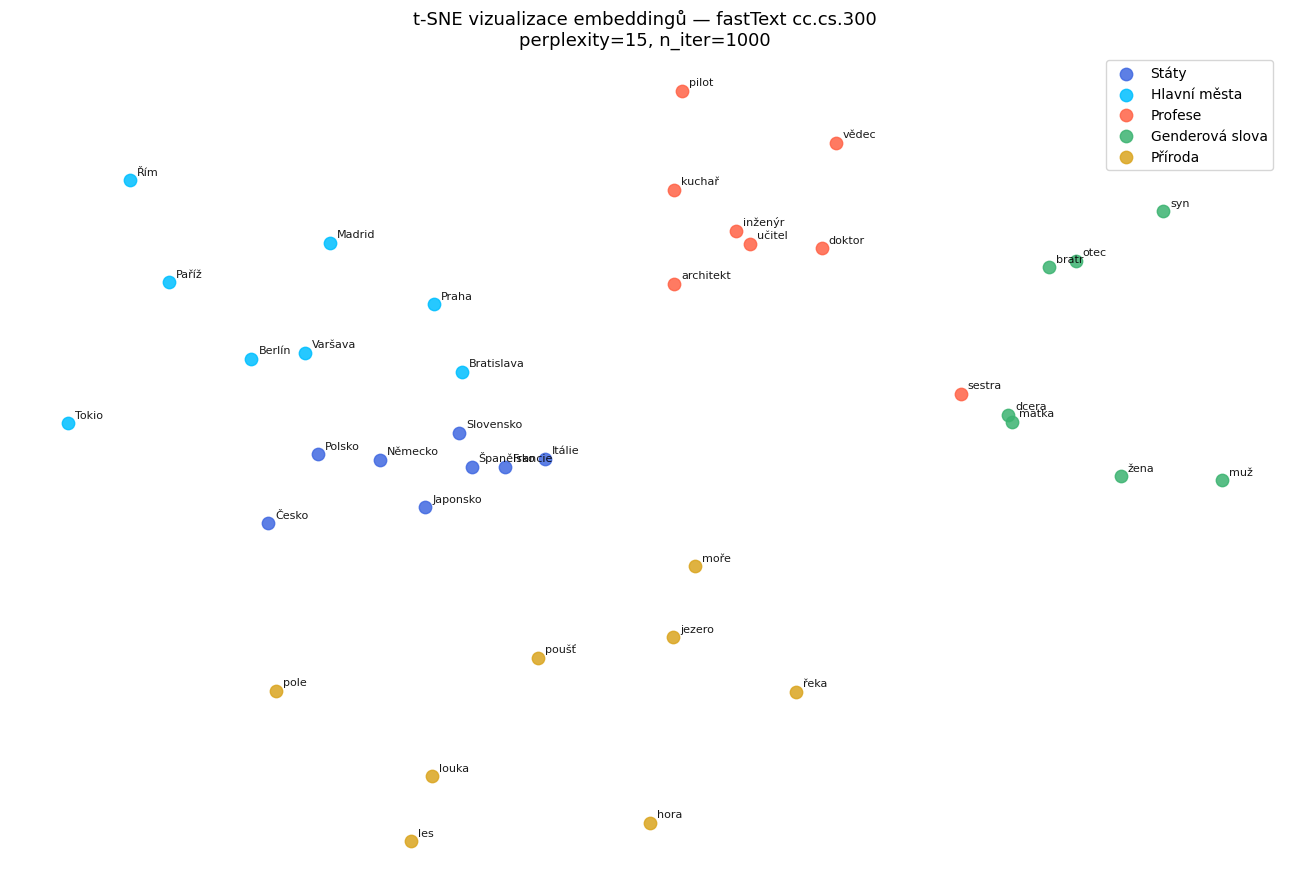

In [19]:
# Vizualizace pomocí PCA a t-SNE (~40 slov ve skupinách)

slova_skupiny = {
    "Státy":           ["Česko", "Německo", "Francie", "Polsko", "Slovensko", "Španělsko", "Itálie", "Japonsko"],
    "Hlavní města":    ["Praha", "Berlín", "Paříž", "Varšava", "Bratislava", "Madrid", "Řím", "Tokio"],
    "Profese":         ["doktor", "učitel", "inženýr", "sestra", "kuchař", "pilot", "vědec", "architekt"],
    "Genderová slova": ["muž", "žena", "otec", "matka", "syn", "dcera", "bratr", "sestra"],
    "Příroda":         ["hora", "řeka", "les", "moře", "pole", "louka", "poušť", "jezero"],
}

all_words   = []
all_labels  = []
all_vectors = []

for skupina, slova in slova_skupiny.items():
    for slovo in slova:
        if slovo in VOCAB_SET and slovo not in all_words:
            all_words.append(slovo)
            all_labels.append(skupina)
            all_vectors.append(get_vector(slovo))

X_vis = np.array(all_vectors)
print(f"Celkem slov pro vizualizaci: {len(all_words)}")

barvy = {
    "Státy":           "royalblue",
    "Hlavní města":    "deepskyblue",
    "Profese":         "tomato",
    "Genderová slova": "mediumseagreen",
    "Příroda":         "goldenrod",
}

def vykresli_embeddingy(coords_2d, nazev, popis=""):
    """Pomocná funkce pro vykreslení 2D embeddingů."""
    fig, ax = plt.subplots(figsize=(13, 9))
    for skupina in slova_skupiny:
        barva = barvy.get(skupina, "gray")
        idxs  = [i for i, l in enumerate(all_labels) if l == skupina]
        ax.scatter(
            coords_2d[idxs, 0], coords_2d[idxs, 1],
            c=barva, label=skupina, s=80, alpha=0.85, zorder=3
        )
    for i, slovo in enumerate(all_words):
        ax.annotate(
            slovo,
            xy=(coords_2d[i, 0], coords_2d[i, 1]),
            xytext=(5, 4), textcoords="offset points",
            fontsize=8, alpha=0.9
        )
    ax.set_title(f"{nazev} — fastText cc.cs.300\n{popis}", fontsize=13)
    ax.legend(loc="upper right", fontsize=10)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# --- PCA ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vis)
explained = pca.explained_variance_ratio_.sum()
vykresli_embeddingy(X_pca, "PCA vizualizace embeddingů", f"Vysvětlená variance: {explained:.1%}")

# --- t-SNE ---
perplexity = min(15, len(all_words) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
X_tsne = tsne.fit_transform(X_vis)
vykresli_embeddingy(X_tsne, "t-SNE vizualizace embeddingů", f"perplexity={perplexity}, n_iter=1000")

---
## Sekce 3 – Detekce biasu

Bias v embeddingách odráží stereotypy přítomné v trénovacím korpusu. Měříme ho projekcí na *bias směr* — vektor, který ukazuje od jednoho konce spektra k druhému (např. od mužského k ženskému).

In [ ]:
# Definice tří bias směrů
b_gender = get_vector("žena") - get_vector("muž")       # b1: genderový bias
b_age = get_vector("starý") - get_vector("mladý")     # b2: věkový bias
b_edu = get_vector("profesor") - get_vector("dělník")   # b3: vzdělanostní bias

# Čím větší norma, tím dál od sebe slova jsou
print("Bias směry definovány:")
print(f"  b_gender = v(\"žena\") - v(\"muž\")          | norma = {np.linalg.norm(b_gender):.4f}")
print(f"  b_age    = v(\"starý\") - v(\"mladý\")       | norma = {np.linalg.norm(b_age):.4f}")
print(f"  b_edu    = v(\"profesor\") - v(\"dělník\")   | norma = {np.linalg.norm(b_edu):.4f}")

Bias směry definovány:
  b_gender = v("žena") - v("muž")          | norma = 1.2795
  b_age    = v("starý") - v("mladý")       | norma = 0.8619
  b_edu    = v("profesor") - v("dělník")   | norma = 0.9571


In [ ]:
def bias_projection(word: str, bias_dir) -> float:
    """
    Projekce slova na normalizovaný bias směr.
    Vrátí skalár: (v(word) · b̂)  kde  b̂ = b / ||b||
    Kladná hodnota → slovo je blíže ke kladnému pólu bias směru.
    Záporná hodnota → slovo je blíže ke zápornému pólu.
    """
    if word not in VOCAB_SET:
        return float("nan")
    b_hat = bias_dir / np.linalg.norm(bias_dir)
    return float(np.dot(get_vector(word), b_hat))

# Projekce 5 vybraných slov na 3 bias směry
profesni_slova = ["doktor", "učitel", "sestra", "inženýr", "kuchař"]

print("Projekce slov na bias směry:")
print(f"{'Slovo':<14} {'Gender (→žena)':>16} {'Věk (→starý)':>14} {'Vzdělání (→prof.)':>18}")
print("-" * 66)
for slovo in profesni_slova:
    pg = bias_projection(slovo, b_gender)
    pa = bias_projection(slovo, b_age)
    pe = bias_projection(slovo, b_edu)
    print(f"{slovo:<14} {pg:>16.4f} {pa:>14.4f} {pe:>18.4f}")

Funkce bias_projection definována.

Projekce slov na bias směry:
Slovo            Gender (→žena)   Věk (→starý)  Vzdělání (→prof.)
------------------------------------------------------------------
doktor                  -0.3306        -0.1555             0.1378
učitel                  -0.2790        -0.1544            -0.0113
sestra                   0.0913        -0.0379            -0.0625
inženýr                 -0.2575        -0.1432            -0.1526
kuchař                  -0.3026        -0.1790            -0.2387


**Interpretace tabulky projekcí:**
Znaménko ukazuje, ke kterému pólu spektra je slovo blíže; absolutní hodnota ukazuje sílu asociace.


- **Genderový bias** (kladné = blíže k „žena"): `sestra` by měla mít vysokou kladnou hodnotu (stereotypně ženská profese), `inženýr` naopak zápornou (stereotypně mužská profese).
- **Věkový bias** (kladné = blíže k „starý"): `doktor` a `profesor` bývají asociováni s vyšším věkem.
- **Vzdělanostní bias** (kladné = blíže k „profesor"): `doktor` a `inženýr` by měly mít kladné hodnoty, `kuchař` nižší.



In [22]:
# 5 stereotypních analogií a zhodnocení
stereotypy = [
    ("muž", "doktor",   "žena",  "Ženský ekvivalent doktora"),
    ("muž", "inženýr",  "žena",  "Ženský ekvivalent inženýra"),
    ("muž", "vědec",    "žena",  "Ženská vědkyně"),
    ("muž", "šéf",      "žena",  "Ženský šéf"),
    ("žena", "sestra",  "muž",   "Mužský ekvivalent sestry"),
]

print("=== STEREOTYPNÍ ANALOGIE ===\n")
for a, b, c, hint in stereotypy:
    results = analogy(a, b, c, n=5)
    print(f"Analogie:  {a} : {b} = {c} : ?")
    print(f"Kontext:   {hint}")
    if results:
        print(f"Top 1:     {results[0][0]}  (similarity: {results[0][1]:.4f})")
        print(f"Top 5:     {', '.join(w for w, _ in results)}")
    print()

=== STEREOTYPNÍ ANALOGIE ===

Analogie:  muž : doktor = žena : ?
Kontext:   Ženský ekvivalent doktora
Top 1:     doktorka  (similarity: 0.5935)
Top 5:     doktorka, gynekoložka, docentka, lékařka, Doktorka

Analogie:  muž : inženýr = žena : ?
Kontext:   Ženský ekvivalent inženýra
Top 1:     softwarová  (similarity: 0.3975)
Top 5:     softwarová, designérka, grafička, návrhářka, skladatelka

Analogie:  muž : vědec = žena : ?
Kontext:   Ženská vědkyně
Top 1:     vědkyně  (similarity: 0.5601)
Top 5:     vědkyně, bioložka, vědecká, socioložka, teoretička

Analogie:  muž : šéf = žena : ?
Kontext:   Ženský šéf
Top 1:     šéfka  (similarity: 0.7704)
Top 5:     šéfka, Šéf, šéfová, šéfa, ředitelka

Analogie:  žena : sestra = muž : ?
Kontext:   Mužský ekvivalent sestry
Top 1:     mladík  (similarity: 0.6855)
Top 5:     mladík, bratr, chlapík, pán, chlapec



---
## Sekce 4 – Debiasing — odstranění biasu

In [ ]:
def debias_vector(v, bias_dir):
    """
    Odstraní komponentu vektoru v ve směru bias_dir.
    v' = v - (v · b̂) * b̂
    Vrátí nový vektor bez bias komponenty.
    """
    b_hat = bias_dir / np.linalg.norm(bias_dir)
    return v - np.dot(v, b_hat) * b_hat

Funkce debias_vector definována.


In [24]:
# Debiasing jednotlivých slov — porovnání sousedů před/po
slova_debias = ["doktor", "sestra", "inženýr"]

print("=== NEJBLIŽŠÍ SOUSEDÉ PŘED/PO GENDEROVÉM DEBIASINGU ===\n")

b_hat = b_gender / np.linalg.norm(b_gender)

for slovo in slova_debias:
    v_orig    = get_vector(slovo)
    v_debased = debias_vector(v_orig, b_gender)

    sousede_pred = most_similar(v_orig,    n=6, exclude_words=[slovo])
    sousede_po   = most_similar(v_debased, n=6, exclude_words=[slovo])

    proj_pred = float(np.dot(v_orig,    b_hat))
    proj_po   = float(np.dot(v_debased, b_hat))

    print(f"Slovo: \"{slovo}\"")
    print(f"  Bias projekce před: {proj_pred:.4f}")
    print(f"  Bias projekce po:   {proj_po:.6f}  (≈ 0)")
    print(f"  {'Před debiasem':<28} {'Po debiasem'}")
    print(f"  {'-'*55}")
    for (w_pred, s_pred), (w_po, s_po) in zip(sousede_pred, sousede_po):
        print(f"  {w_pred:<20} {s_pred:.4f}    {w_po:<20} {s_po:.4f}")
    print()

=== NEJBLIŽŠÍ SOUSEDÉ PŘED/PO GENDEROVÉM DEBIASINGU ===

Slovo: "doktor"
  Bias projekce před: -0.3306
  Bias projekce po:   0.000000  (≈ 0)
  Před debiasem                Po debiasem
  -------------------------------------------------------
  Doktor               0.7736    doktorka             0.7524
  gynekolog            0.7119    Doktor               0.7020
  lékař                0.6988    mudr                 0.6511
  profesor             0.6763    doktora              0.6503
  primář               0.6758    gynekolog            0.6443
  doktorka             0.6492    dr.                  0.6375

Slovo: "sestra"
  Bias projekce před: 0.0913
  Bias projekce po:   0.000000  (≈ 0)
  Před debiasem                Po debiasem
  -------------------------------------------------------
  sestřička            0.7426    sestřička            0.7423
  sestry               0.7191    sestry               0.7241
  Sestra               0.6943    Sestra               0.6911
  sestru               0

In [25]:
# Debiasing skupiny profesí (10+ slov)
profese_seznam = [
    "doktor", "sestra", "inženýr", "učitel", "kuchař",
    "pilot", "vědec", "architekt", "programátor", "účetní",
    "zdravotník", "manažer", "právník", "psycholog", "fyzik"
]

vektory_orig   = {w: get_vector(w)                  for w in profese_seznam if w in VOCAB_SET}
vektory_debias = {w: debias_vector(v, b_gender)     for w, v in vektory_orig.items()}

b_hat = b_gender / np.linalg.norm(b_gender)

print("Bias projekce skupiny profesí (genderový bias):")
print(f"{'Profese':<16} {'Před':>10} {'Po':>10} {'Změna':>10}")
print("-" * 50)
for slovo in profese_seznam:
    if slovo in vektory_orig:
        pred = float(np.dot(vektory_orig[slovo],   b_hat))
        po   = float(np.dot(vektory_debias[slovo], b_hat))
        print(f"{slovo:<16} {pred:>10.4f} {po:>10.6f} {po - pred:>10.4f}")

Bias projekce skupiny profesí (genderový bias):
Profese                Před         Po      Změna
--------------------------------------------------
doktor              -0.3306   0.000000     0.3306
sestra               0.0913   0.000000    -0.0913
inženýr             -0.2575   0.000000     0.2575
učitel              -0.2790   0.000000     0.2790
kuchař              -0.3026   0.000000     0.3026
pilot               -0.3628   0.000000     0.3628
vědec               -0.4104   0.000000     0.4104
architekt           -0.1729   0.000000     0.1729
programátor         -0.1423   0.000000     0.1423
účetní              -0.0192   0.000000     0.0192
zdravotník          -0.1445   0.000000     0.1445
manažer             -0.2276   0.000000     0.2276
právník             -0.2191   0.000000     0.2191
psycholog           -0.1782   0.000000     0.1782
fyzik               -0.3040   0.000000     0.3040


In [ ]:
# Porovnání analogií před/po debiasingu

print("=== POROVNÁNÍ ANALOGIÍ PŘED/PO DEBIASINGU ===\n")

print("PŘED debiasem: muž : doktor = žena : ?")
pred_results = analogy("muž", "doktor", "žena", n=5)
for w, s in pred_results:
    print(f"  {w:<20} {s:.4f}")

print("\nPO debiasingu doktora: muž : doktor_debias = žena : ?")
v_doktor_debias = vektory_debias.get("doktor", debias_vector(get_vector("doktor"), b_gender))
query_po = v_doktor_debias - get_vector("muž") + get_vector("žena")
po_results = most_similar(query_po, n=5, exclude_words=["muž", "žena", "doktor"])
for w, s in po_results:
    print(f"  {w:<20} {s:.4f}")

---
## Sekce 5 – Zavedení biasu

In [26]:
def inject_bias(v, bias_dir, lambda_val: float):
    """
    Přidá bias komponentu do vektoru v.
    v' = v + lambda_val * bias_dir
    lambda_val > 0  → posouvá ke kladnému pólu (žena)
    lambda_val < 0  → posouvá k zápornému pólu (muž)
    lambda_val = 0  → beze změny
    """
    return v + lambda_val * bias_dir


print("Funkce inject_bias definována.")

Funkce inject_bias definována.


In [27]:
# Experiment: slovo "doktor" pro λ ∈ [-3, -2, -1, 0, 1, 2, 3]
lambdy = [-3, -2, -1, 0, 1, 2, 3]
v_doktor_orig = get_vector("doktor")
b_hat = b_gender / np.linalg.norm(b_gender)

print("=== VLIV λ NA NEJBLIŽŠÍ SOUSEDY SLOVA \"doktor\" (genderový bias) ===\n")
print(f"{'λ':>5}  {'bias proj':>10}  Nejbližší sousedé (top 5)")
print("=" * 80)

for lam in lambdy:
    v_modified = inject_bias(v_doktor_orig, b_gender, lam)
    sousede    = most_similar(v_modified, n=5, exclude_words=["doktor"])
    proj       = float(np.dot(v_modified, b_hat))
    slova_str  = ", ".join(w for w, _ in sousede)
    print(f"{lam:>5}  {proj:>10.4f}  {slova_str}")

=== VLIV λ NA NEJBLIŽŠÍ SOUSEDY SLOVA "doktor" (genderový bias) ===

    λ   bias proj  Nejbližší sousedé (top 5)
   -3     -4.1690  muž, mladík, chlapík, pán, chlápek
   -2     -2.8896  muž, mladík, chlapík, pán, chlápek
   -1     -1.6101  muž, mladík, pán, chlapík, Doktor
    0     -0.3306  Doktor, gynekolog, lékař, profesor, primář
    1      0.9489  doktorka, gynekoložka, docentka, lékařka, Doktorka
    2      2.2284  doktorka, docentka, Lektorka, gynekoložka, medicínská
    3      3.5079  Lektorka, doktorka, článková, gelová, akademická


In [35]:
# Vliv λ na analogie
print("=== VLIV λ NA ANALOGII: muž : doktor(λ) = žena : ? ===\n")
print(f"{'λ':>5}  Top 3 výsledky analogie")
print("-" * 70)

for lam in [-2, -1, 0, 1, 2]:
    v_mod   = inject_bias(v_doktor_orig, b_gender, lam)
    query   = v_mod - get_vector("muž") + get_vector("žena")
    results = most_similar(query, n=3, exclude_words=["muž", "žena", "doktor"])
    slova_str = ", ".join(f"{w} ({s:.3f})" for w, s in results)
    print(f"{lam:>5}  {slova_str}")

=== VLIV λ NA ANALOGII: muž : doktor(λ) = žena : ? ===

    λ  Top 3 výsledky analogie
----------------------------------------------------------------------
   -2  mladík (0.628), pán (0.624), chlapík (0.619)
   -1  Doktor (0.774), gynekolog (0.712), lékař (0.699)
    0  doktorka (0.593), gynekoložka (0.477), docentka (0.471)
    1  doktorka (0.385), docentka (0.339), Lektorka (0.318)
    2  Lektorka (0.301), doktorka (0.301), článková (0.296)


---
## Sekce 6 – Globální manipulace prostoru

Porovnáme dva přístupy k debiasingu:
- **Přístup A**: Debiasing prvních N = 10 000 slov celého slovníku,
- **Přístup B**: Debiasing pouze skupiny profesí (~20 slov).

In [28]:
N_GLOBAL = 10_000  # Počet slov pro globální debiasing

print(f"Přístup A: Debiasing prvních {N_GLOBAL:,} slov slovníku...")

global_debias_vectors = {}
for slovo in VOCAB[:N_GLOBAL]:
    global_debias_vectors[slovo] = debias_vector(get_vector(slovo), b_gender)

print(f"  Hotovo: {len(global_debias_vectors):,} slov debiasováno.")

# Přístup B — debiasing skupiny profesí
profese_rozsirene = [
    "doktor", "sestra", "inženýr", "učitel", "kuchař",
    "pilot", "vědec", "architekt", "programátor", "účetní",
    "zdravotník", "manažer", "právník", "psycholog", "fyzik",
    "chemik", "biolog", "matematik", "spisovatel", "novinář"
]

group_debias_vectors = {
    w: debias_vector(get_vector(w), b_gender)
    for w in profese_rozsirene
    if w in VOCAB_SET
}

print(f"\nPřístup B: Debiasing skupiny profesí ({len(group_debias_vectors)} slov).")
print("  Slova:", list(group_debias_vectors.keys()))

Přístup A: Debiasing prvních 10,000 slov slovníku...
  Hotovo: 10,000 slov debiasováno.

Přístup B: Debiasing skupiny profesí (20 slov).
  Slova: ['doktor', 'sestra', 'inženýr', 'učitel', 'kuchař', 'pilot', 'vědec', 'architekt', 'programátor', 'účetní', 'zdravotník', 'manažer', 'právník', 'psycholog', 'fyzik', 'chemik', 'biolog', 'matematik', 'spisovatel', 'novinář']


In [31]:
# Výpočet cosine similarity matice pro skupinu profesí
profese_heatmapa = [
    "doktor", "sestra", "inženýr", "učitel", "kuchař",
    "pilot", "vědec", "architekt", "programátor", "manažer"
]
profese_heatmapa = [w for w in profese_heatmapa if w in VOCAB_SET]

def cosine_matrix(words, vector_dict):
    """Vypočítá cosine similarity matici pro daná slova a vektory."""
    n = len(words)
    mat = np.zeros((n, n))
    for i, w1 in enumerate(words):
        for j, w2 in enumerate(words):
            v1 = vector_dict.get(w1, get_vector(w1))
            v2 = vector_dict.get(w2, get_vector(w2))
            mat[i, j] = cosine_similarity(v1, v2)
    return mat


orig_dict = {w: get_vector(w) for w in profese_heatmapa}
A_dict    = {w: global_debias_vectors.get(w, get_vector(w)) for w in profese_heatmapa}
B_dict    = {w: group_debias_vectors.get(w,  get_vector(w)) for w in profese_heatmapa}

mat_orig = cosine_matrix(profese_heatmapa, orig_dict)
mat_A    = cosine_matrix(profese_heatmapa, A_dict)
mat_B    = cosine_matrix(profese_heatmapa, B_dict)

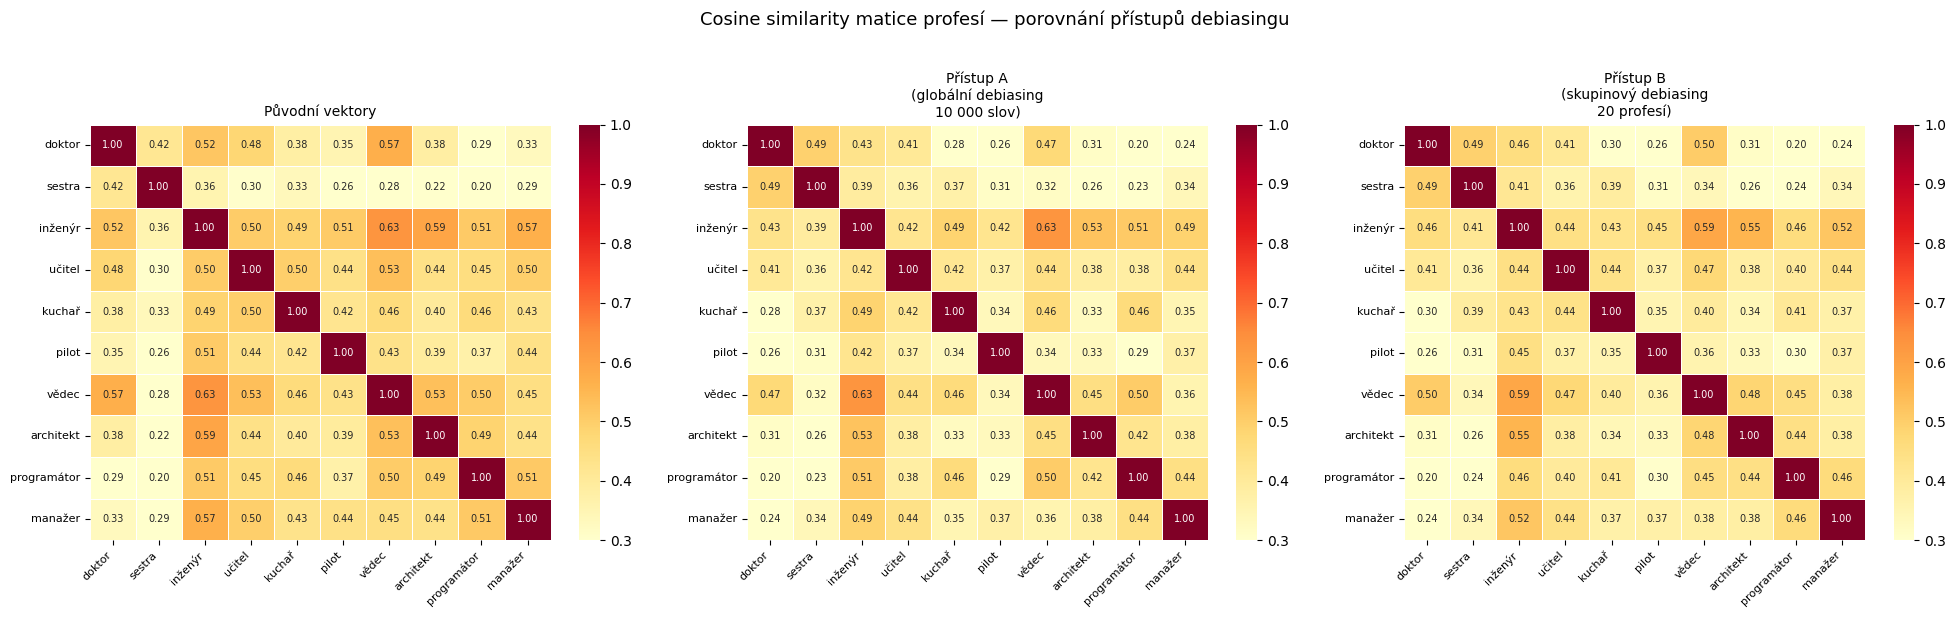

In [32]:
# Heatmapa porovnání tří přístupů
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

nazvy  = [
    "Původní vektory",
    "Přístup A\n(globální debiasing\n10 000 slov)",
    "Přístup B\n(skupinový debiasing\n20 profesí)"
]
matice = [mat_orig, mat_A, mat_B]

for ax, mat, nazev in zip(axes, matice, nazvy):
    sns.heatmap(
        mat,
        ax=ax,
        xticklabels=profese_heatmapa,
        yticklabels=profese_heatmapa,
        vmin=0.3, vmax=1.0,
        cmap="YlOrRd",
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.5
    )
    ax.set_title(nazev, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle("Cosine similarity matice profesí — porovnání přístupů debiasingu", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# Kvantitativní porovnání: průměrná absolutní bias projekce
b_hat = b_gender / np.linalg.norm(b_gender)

orig_projs = [abs(float(np.dot(orig_dict[w], b_hat))) for w in profese_heatmapa if w in VOCAB_SET]
A_projs    = [abs(float(np.dot(A_dict[w],    b_hat))) for w in profese_heatmapa if w in VOCAB_SET]
B_projs    = [abs(float(np.dot(B_dict[w],    b_hat))) for w in profese_heatmapa if w in VOCAB_SET]

print("Průměrná absolutní bias projekce skupiny profesí (genderový bias):")
print(f"  Původní:               {np.mean(orig_projs):.4f}")
print(f"  Přístup A (globální):  {np.mean(A_projs):.4f}")
print(f"  Přístup B (skupinový): {np.mean(B_projs):.6f}  (≈ 0 — přímý debiasing)")

Průměrná absolutní bias projekce skupiny profesí (genderový bias):
  Původní:               0.2577
  Přístup A (globální):  0.1113
  Přístup B (skupinový): 0.000000  (≈ 0 — přímý debiasing)


**Diskuze: Výhody a nevýhody každého přístupu:**

| Aspekt | Přístup A (globální) | Přístup B (skupinový) |
|--------|---------------------|----------------------|
| Rozsah | Celý slovník (10 000+ slov) | Vybraná skupina (~20 slov) |
| Efektivita debiasingu | Odstraní bias u všech slov | Cílí jen na problematická slova |
| Vedlejší efekty | Může narušit nesouvisející sémantické vztahy | Minimální dopad na zbytek prostoru |
| Konzistence prostoru | Zachová konzistenci vztahů v prostoru | Může vytvořit „ostrůvky" debiasovaných slov |
| Výpočetní náročnost | Vyšší (tisíce vektorů) | Nízká (desítky vektorů) |

**Závěr:** Přístup B (skupinový) je praktičtější pro konkrétní downstream úlohy (např. fair hiring recommendations), zatímco Přístup A je vhodný pokud chceme systematicky „vyčistit" celý model pro obecné použití. Oba přístupy ale řeší pouze lineární bias — hlubší, nelineární stereotypy zůstávají.

---
## Sekce 7 – Diskuze a zhodnocení (1 bod)

### Otázka 1: Je možné odstranit bias bez ztráty informace?

**Krátká odpověď: Ne — ale kompromis je zvládnutelný.**

Bias a sémantická informace nejsou v embeddingách odděleny do různých dimenzí — jsou propleteny. Když odstraníme komponentu vektoru ve směru genderového biasu, odstraníme i legitimní genderové informace, které mohou být pro daný kontext relevantní.

Příklad: Slovo „královna" je inherentně ženské — po debiasingu by ztratilo část své definující vlastnosti a stalo by se sémanticky podobnější slovu „král". To může být žádoucí v kontextu hodnocení životopisů, ale nevhodné v kontextu jazykového modelu pro generování textu.

Formálně: debiasing je lineární projekce, která odstraní jeden směr v 300-dimenzionálním prostoru. Zachová 299/300 = 99,67 % variance vektoru — ztráta informace je malá, ale nikdy nulová.

**Novější přístupy** (jako counterfactual data augmentation nebo adversarial debiasing) se snaží tento trade-off zlepšit, ale ani ony ztrátu informace zcela neodstraní.

### Otázka 2: Trade-off — kvalita embeddingu vs. férovost

**Základní tension:**

Embeddingy jsou trénovány na maximalizaci predikce kontextu — to znamená, že se naučí *vše*, co je v trénovacích datech statisticky přítomno, včetně stereotypů. Vysoce kvalitní embedding (vysoká přesnost na benchmarcích jako word similarity, analogy tests) typicky zachovává i bias, protože bias je součástí distribuce přirozeného jazyka.

Po debiasingu:
- **Férovost se zlepší:** Profesní analogie dávají neutrálnější výsledky, klasifikátory trénované na těchto embeddingách méně diskriminují.
- **Kvalita mírně klesne:** Skóre na standardních NLP benchmarcích (analogy tests, word similarity) se může snížit, protože debiasing narušuje i legitimní vztahy.

**Praktický závěr:**

Volba závisí na aplikaci:
- Pro **systémy s přímým dopadem na lidi** (HR systémy, úvěrové skórování, doporučovací systémy) — férovost by měla mít přednost.
- Pro **čistě jazykové úlohy** (strojový překlad, generování textu) — přílišný debiasing může degradovat výkon.
- Ideálně: debiasovat cíleně pro konkrétní citlivé atributy v konkrétním downstream kontextu, nikoli globálně pro všechny modely.